In [1]:
from sklearn.datasets import make_swiss_roll

x , color = make_swiss_roll(n_samples=10000 ,  random_state=42)
x.shape


(10000, 3)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


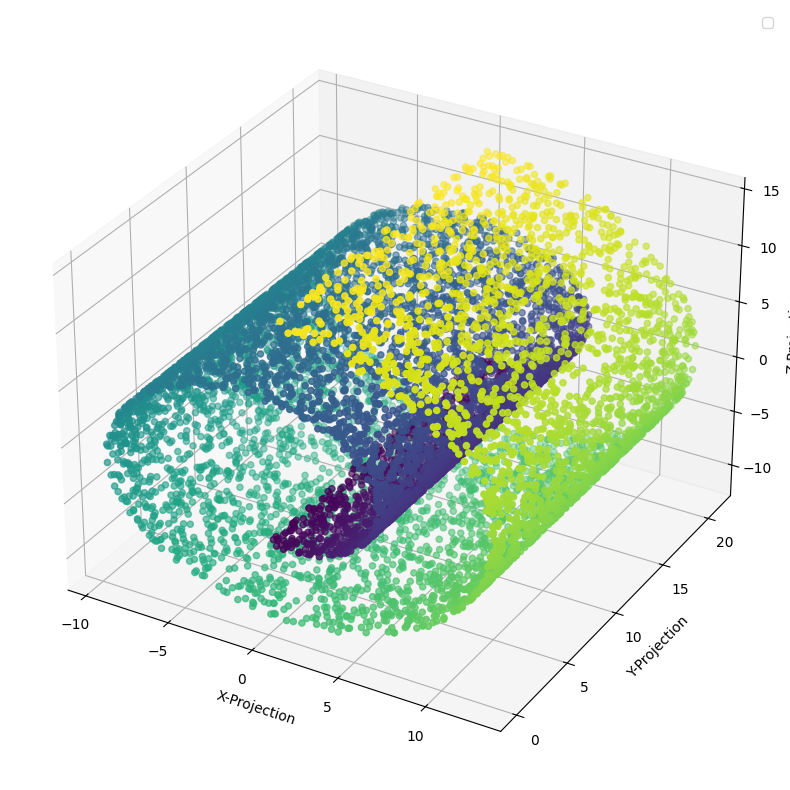

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=color)

# Use ax methods for 3D plots
ax.set_xlabel("X-Projection")
ax.set_ylabel("Y-Projection")
ax.set_zlabel("Z-Projection")

ax.legend()  # Also use ax.legend() for 3D, and fix typo
plt.show()

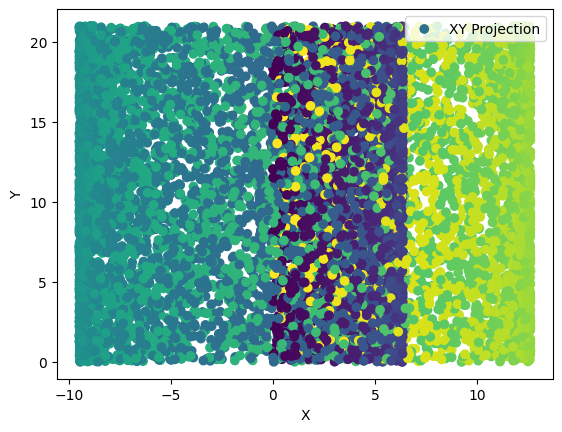

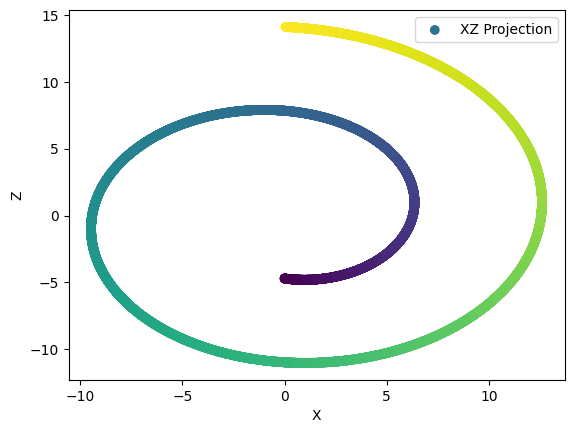

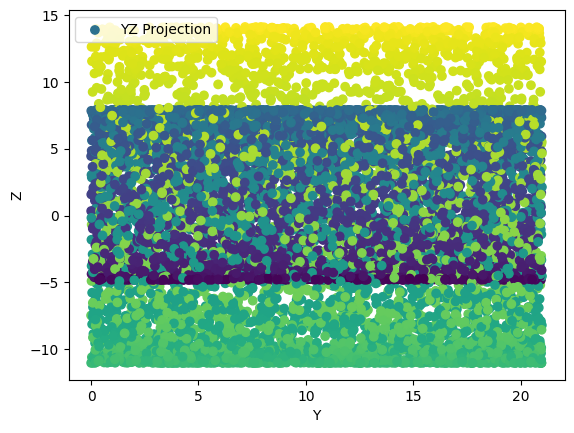

In [3]:
# Projection onto X-Y plane (ignoring Z)
plt.scatter(x[:, 0], x[:, 1], label="XY Projection", c=color, cmap="viridis")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Projection onto X-Z plane (ignoring Y)
plt.scatter(x[:, 0], x[:, 2], label="XZ Projection", c=color, cmap="viridis")
plt.xlabel("X")
plt.ylabel("Z")
plt.legend()
plt.show()

# Projection onto Y-Z plane (ignoring X)
plt.scatter(x[:, 1], x[:, 2], label="YZ Projection", c=color, cmap="viridis")
plt.xlabel("Y")
plt.ylabel("Z")
plt.legend()
plt.show()


In [4]:
import numpy as np

x_centre = x - x.mean(axis= 0)
u , s , v = np.linalg.svd(x_centre)
c1 = v.T[: , 0] 
c2 = v.T[: , 1] 
c3 = v.T[: , 2]

In [5]:
w = v.T[: , :2]
print(w)
x_transformed = x_centre.dot(w)


[[ 0.53848397  0.84221422]
 [-0.01399894  0.04056407]
 [ 0.84251946 -0.53761488]]


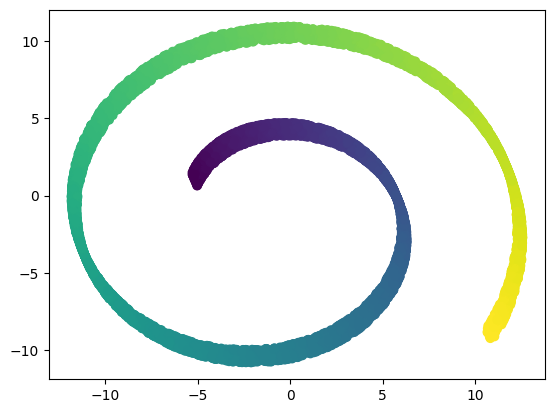

In [6]:
plt.scatter(x_transformed[: , 0] , x_transformed[: , 1] , label="Transformed_Data" , c=color)
plt.show()

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)
x_transformed = pca.fit_transform(x)
print(pca.explained_variance_ratio_) #Since PCA is a linear model and the Swiss roll is a non-linear model it fails to retain variance

[0.39314412 0.31950797]


In [8]:
#Ways to calculate the d
#1. 
pca_1 = PCA()
pca_1.fit(x)
cumsum = np.cumsum(pca_1.explained_variance_ratio_)
d = np.argmax(cumsum>=0.95) + 1 #Where 0.95 is our target variance to be preserved

In [9]:
#2. 
pca_2 = PCA(n_components= 0.95) #Where mentioning 0.0 to 1.0 it passes the variance we want to preserve

In [10]:
#3. Elbow by plotting the cumsum

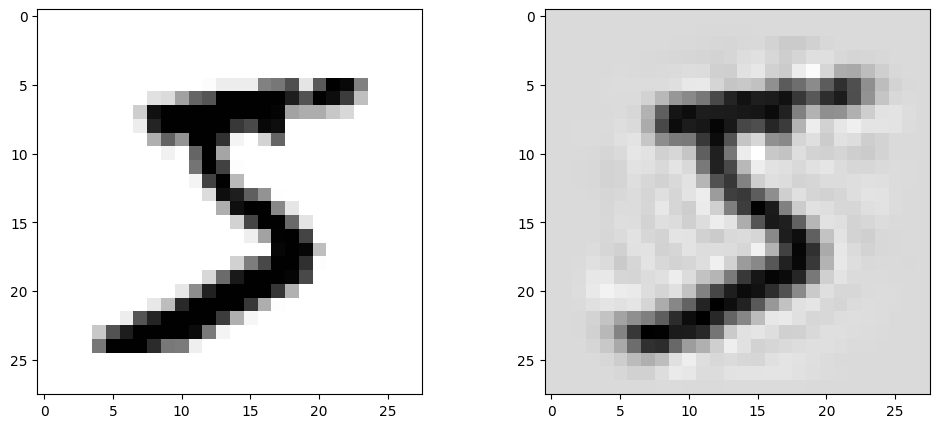

In [11]:
from sklearn.datasets import fetch_openml
import matplotlib

fig , (ax1 , ax2) = plt.subplots(1 , 2 , figsize = (12, 5))
mnist = fetch_openml("mnist_784" , version= 1)
x_mnist  = mnist.data
y_mnist = mnist.target

x_somedigit = x_mnist.iloc[0]
x_some_image = x_somedigit.values.reshape(28 , 28)
ax1.imshow(x_some_image , cmap=matplotlib.cm.binary , interpolation="nearest")

#Since even tho we compressed and decompressed since orignally when compressing there is some variance loss
pca = PCA(n_components= 154)
x_mnist_reduced = pca.fit_transform(x_mnist)

x_mnist_inversed = pca.inverse_transform(x_mnist_reduced)
x_reduced  = x_mnist_inversed[0]
x_milako = x_reduced.reshape(28 , 28)
ax2.imshow(x_milako , cmap= matplotlib.cm.binary , interpolation="nearest")

In [12]:
from sklearn.decomposition import IncrementalPCA
#Here we don't need to pass the whole datast to train the model
n_batches = 100
increment_pca = IncrementalPCA(n_components= 154)
for x_batch in np.array_split(x_mnist , n_batches):
    increment_pca.partial_fit(x_batch)

x_gataiyo_hai = increment_pca.transform(x_mnist)
x_gataiyo_hai.shape

c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


(70000, 154)

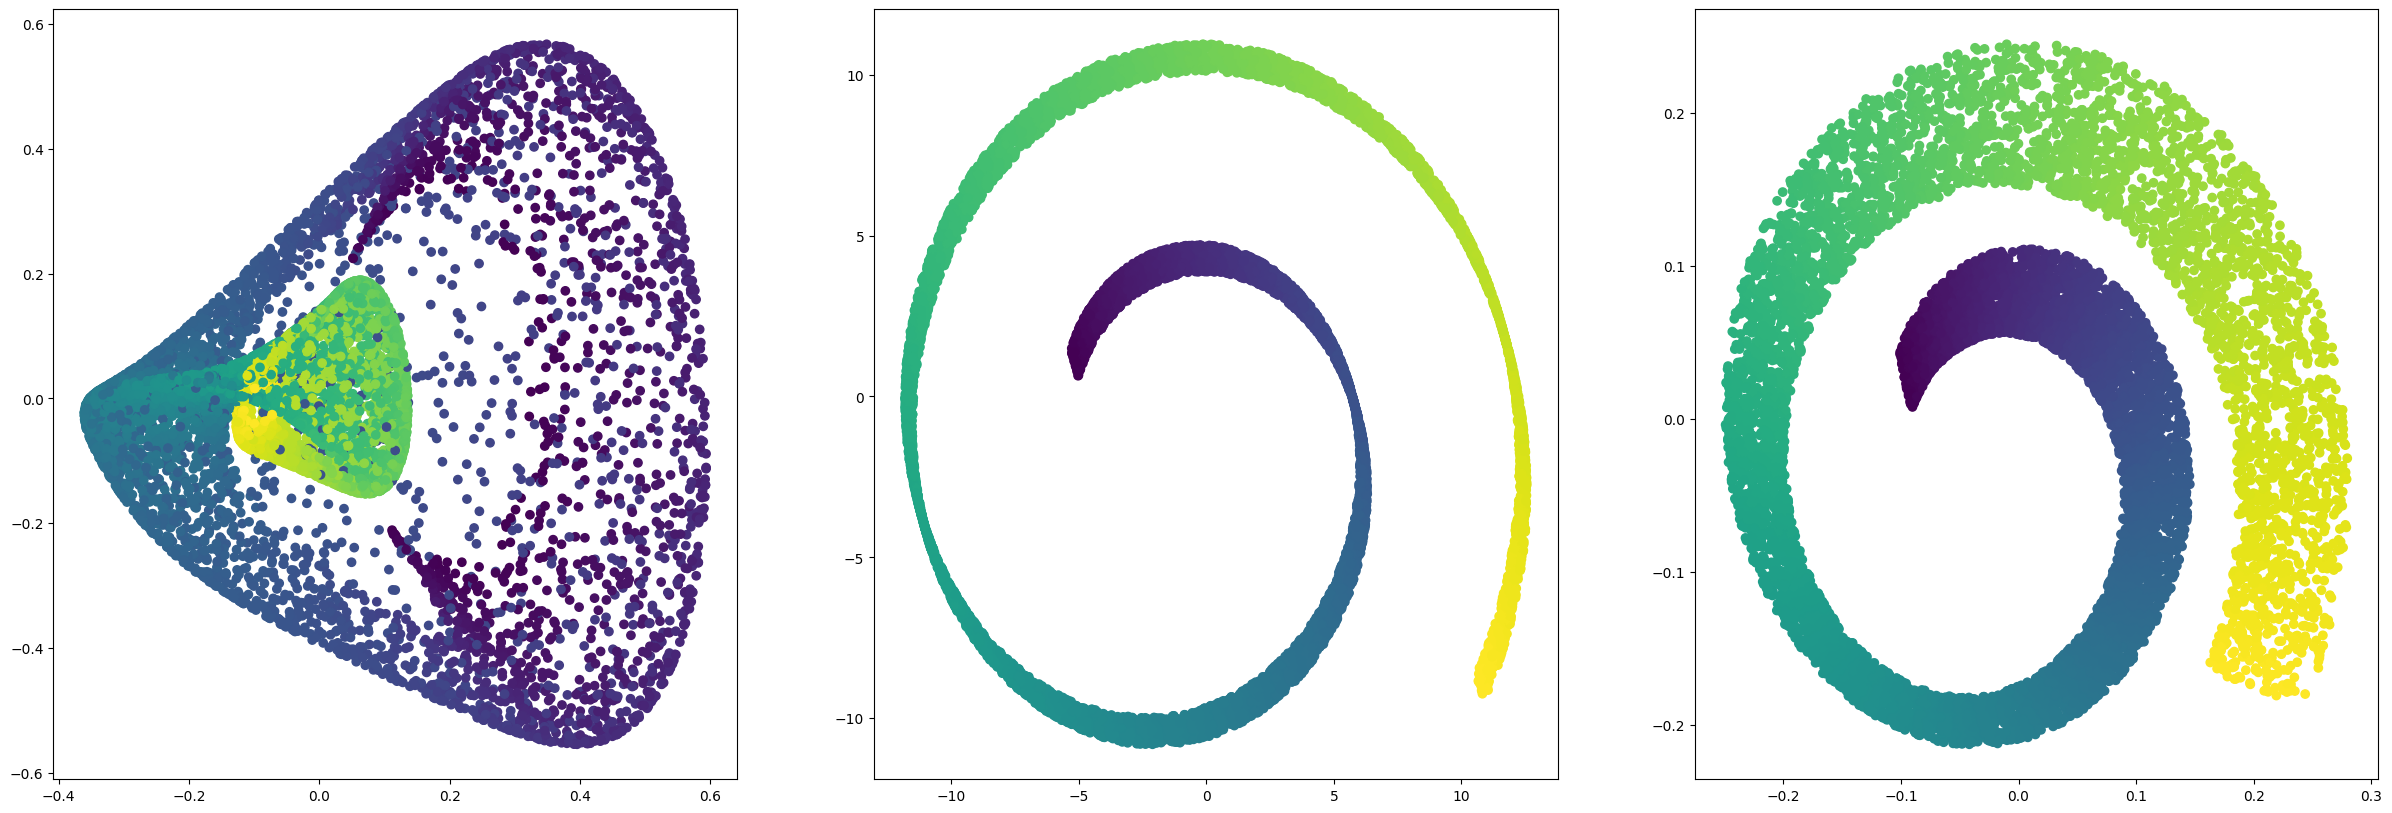

In [13]:
from sklearn.decomposition import KernelPCA


fig , (ax1 , ax2 , ax3) = plt.subplots(1 , 3 , figsize = (30 , 10))

rbf_pca = KernelPCA(n_components= 2,kernel= "rbf"  , gamma= 0.04)
linear_pca = KernelPCA(kernel= "linear" , n_components= 2) 
sigmoid_pca = KernelPCA(kernel= "sigmoid" , n_components= 2 , gamma= 0.001 ,coef0= 1)
x_reduced = rbf_pca.fit_transform(x)
x_reduced_linear = linear_pca.fit_transform(x)
x_reduced_sigmoid = sigmoid_pca.fit_transform(x)
ax1.scatter(x_reduced[: , 0] , x_reduced[: , 1] , c = color )
ax2.scatter(x_reduced_linear[: , 0] , x_reduced_linear[: , 1] , c = color )
ax3.scatter(x_reduced_sigmoid[: , 0] , x_reduced_sigmoid[: , 1] , c = color )

In [14]:
x_data = x_mnist[:1000]
y_target = y_mnist[:1000]


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


In [16]:
sgl_clf  = Pipeline([
    ("model" , KernelPCA(n_components= 100)),
    ("classifier" , LogisticRegression())
])

param_grid = [{
    "model__gamma" : np.linspace(0.03 , 0.05 , 10),
    "model__kernel": ["rbf" , "sigmoid"]
}]

grid_search = GridSearchCV(sgl_clf , param_grid , cv= 2 , n_jobs= -1 )
grid_search.fit(x_data , y_target)

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('model', KernelPCA(n_components=100)),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'model__gamma': array([0.03      , 0.03222222, 0.03444444, 0.03666667, 0.03888889,
       0.04111111, 0.04333333, 0.04555556, 0.04777778, 0.05      ]),
                          'model__kernel': ['rbf', 'sigmoid']}])

In [17]:
grid_search.best_estimator_

Pipeline(steps=[('model',
                 KernelPCA(gamma=0.03, kernel='rbf', n_components=100)),
                ('classifier', LogisticRegression())])

In [18]:
kernel_12 = KernelPCA(kernel= "rbf" , n_components= 124 , fit_inverse_transform  = True )
x_data_reduced_1 = kernel_12.fit_transform(x_data)
x_pre_image = kernel_12.inverse_transform(x_data_reduced_1)

In [21]:
from sklearn.manifold import LocallyLinearEmbedding

local_liner = LocallyLinearEmbedding(n_components= 2 , n_neighbors= 10)
x_reduced_2 = local_liner.fit_transform(x)

[]

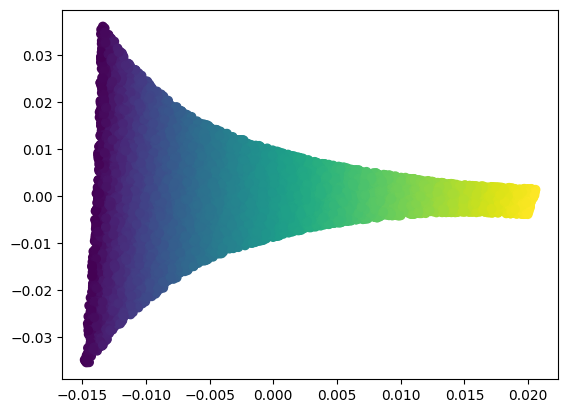

In [22]:
plt.scatter(x_reduced_2[: , 0] , x_reduced_2[: , 1] , c= color , cmap="viridis")
plt.plot()